## Reproducibility and evaluation discipline

I fix a global random seed and print package versions at the start. This makes the subsampling, the train/test split, SMOTE, and training runs repeatable across different machines.

To keep evaluation fair, the test set is held out once and used only for final reporting. Standardisation is fitted using training data only. SMOTE is applied only to training data inside cross-validation folds, never to validation folds and never to the test set.

For fairness, I first compare an MLP trained without SMOTE against an SVM trained on the original imbalanced data using class_weight="balanced". I then evaluate SMOTE as an extension for the MLP and discuss the performance and runtime trade-offs.

In [1]:
import sys
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display  # makes display(...) explicit for fresh-kernel runs

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score,
    confusion_matrix, roc_curve
)
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# I use a fixed seed so the subsample, splits, SMOTE resampling, and model initialisation are repeatable.
# SEED=42 also matches my group coursework setup, making comparisons cleaner.
SEED = 42


def set_global_seed(seed: int = 42) -> None:
    """
    Set random seeds for reproducibility.

    This reduces run-to-run randomness in NumPy, PyTorch, and Python's built-in
    random module. I also enable deterministic cuDNN behaviour, when available,
    to make GPU runs more repeatable.
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Determinism improves repeatability (may reduce speed).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(SEED)

# Print versions to make the environment used for the results explicit.
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)
print("imblearn:", __import__("imblearn").__version__)
print("torch:", torch.__version__)

ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data"
FIGURES_DIR = ROOT / "figures"
MODELS_DIR = ROOT / "models"

# Create folders so saving works on a clean machine.
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR   :", DATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("MODELS_DIR :", MODELS_DIR)

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1
imblearn: 0.13.0
torch: 2.10.0+cpu
DATA_DIR   : C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\data
FIGURES_DIR: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\figures
MODELS_DIR : C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models


## Dataset choice, task definition, and metrics

Dataset: I use the BRFSS 2015 health indicators dataset (Kaggle file name: `diabetes_012_health_indicators_BRFSS2015.csv`). It is freely accessible and widely used in public health machine learning research to model diabetes predictors such as BMI, health behaviours, healthcare access, and demographic factors (Xie et al., 2019). This makes it an excellent benchmark for comparing a non-linear MLP versus SVM.

The dataset originates from the CDC BRFSS 2015 public survey; the Kaggle file is used as a convenient mirror of the same public data.

Features: the input contains 21 health indicators, including blood pressure and cholesterol flags, BMI, smoking, activity and diet indicators, healthcare access, and demographic factors such as age, education, and income. These factors can interact, so I expect non-linear structure.

Target: to match the group baseline fairly, I convert the original 3-class label into a binary target using `y = (Diabetes_012 > 0)`. This means the positive class includes pre-diabetes and diabetes (classes 1 and 2).

Metrics: the data is imbalanced, so accuracy on its own can be misleading. I prioritise recall because false negatives are costly in screening-style tasks, and I report AUC because it measures discrimination across thresholds. Confusion matrices are included so TN, FP, FN, and TP can be discussed directly.

In [2]:
DATA_PATH_CANDIDATES = [
    DATA_DIR / "diabetes_012_health_indicators_BRFSS2015.csv",
    ROOT / "diabetes_012_health_indicators_BRFSS2015.csv",
]

DATA_PATH = None
for p in DATA_PATH_CANDIDATES:
    if p.exists():
        DATA_PATH = p
        break

assert DATA_PATH is not None, (
    "CSV file not found. Put it in either:\n"
    "1) data/diabetes_012_health_indicators_BRFSS2015.csv (recommended)\n"
    "or\n"
    "2) ./diabetes_012_health_indicators_BRFSS2015.csv (project root)"
)

TARGET_COL = "Diabetes_012"
SAMPLE_SIZE = 100_000  # match the group baseline setup for fair comparison

df = pd.read_csv(DATA_PATH)
print("Loaded CSV from:", DATA_PATH)
print("Full dataset shape:", df.shape)

# Group baseline target conversion:
# 0 stays 0, classes 1 and 2 become 1

y_raw = df[TARGET_COL].to_numpy()
y_full = (y_raw > 0).astype(int)

X_full = df.drop(columns=[TARGET_COL]).to_numpy(dtype=np.float32)

print("X_full:", X_full.shape, "y_full:", y_full.shape)
print("Positive rate (full):", float(y_full.mean()))

# Stratified subsample to exactly 100,000 (preserves imbalance)
all_idx = np.arange(len(y_full))
sub_idx, _ = train_test_split(
    all_idx,
    train_size=SAMPLE_SIZE,
    stratify=y_full,
    random_state=SEED
)

X = X_full[sub_idx]
y = y_full[sub_idx]

# Save subsample indices so the exact 100,000-row dataset can be reconstructed later if needed.
np.save(MODELS_DIR / "sub_idx.npy", sub_idx)
print("Saved subsample indices to:", MODELS_DIR / "sub_idx.npy")

print("Subsampled X:", X.shape, "y:", y.shape)
print("Positive rate (subsample):", float(y.mean()))

Loaded CSV from: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\diabetes_012_health_indicators_BRFSS2015.csv
Full dataset shape: (253680, 22)
X_full: (253680, 21) y_full: (253680,)
Positive rate (full): 0.15758830022075054
Saved subsample indices to: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\sub_idx.npy
Subsampled X: (100000, 21) y: (100000,)
Positive rate (subsample): 0.15759


## Train/test split

I use an 80/20 stratified split, matching the group coursework setup. Stratification keeps the positive class rate consistent in both splits, which matters when the data is imbalanced.

The test set is held out once and used only for final reporting. Hyperparameters are selected using cross-validation on the training set.

In [3]:
# Stratified split keeps prevalence consistent between train and test.
# I split indices first so the saved indices and the resulting arrays are guaranteed to match exactly.
idx_100k = np.arange(len(y))
train_idx, test_idx = train_test_split(
    idx_100k,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

np.save(MODELS_DIR / "train_idx.npy", train_idx)
np.save(MODELS_DIR / "test_idx.npy", test_idx)
print("Saved split indices to:", MODELS_DIR / "train_idx.npy", "and", MODELS_DIR / "test_idx.npy")

print("Train:", X_train.shape, y_train.shape, "pos rate:", float(y_train.mean()))
print("Test :", X_test.shape, y_test.shape, "pos rate:", float(y_test.mean()))

Saved split indices to: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\train_idx.npy and C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\test_idx.npy
Train: (80000, 21) (80000,) pos rate: 0.1575875
Test : (20000, 21) (20000,) pos rate: 0.1576


## Standardisation

I standardise features using z-scores.

For the SVM with an RBF kernel, distance and similarity are central, so different feature scales can distort the kernel.

For the MLP, gradient-based training is more stable when inputs are on a similar scale.

To avoid data leakage, the scaler is fitted on the training set only and then applied to the test set using the same parameters.

In [4]:
# Fit on training only to avoid leaking test-set statistics into preprocessing.
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print("Standardised shapes:", X_train_std.shape, X_test_std.shape)

# Save the standardised test set so the final saved models can be evaluated without recomputing preprocessing.
# I save only the standardised TEST set and labels to enable evaluation without rerunning preprocessing/training.
# I do not save the full training arrays to keep the submission size smaller.
np.save(MODELS_DIR / "X_test_std.npy", X_test_std)
np.save(MODELS_DIR / "y_test.npy", y_test)
print("Saved:", MODELS_DIR / "X_test_std.npy")
print("Saved:", MODELS_DIR / "y_test.npy")

Standardised shapes: (80000, 21) (20000, 21)
Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\X_test_std.npy
Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\y_test.npy


## Class imbalance and SMOTE

This dataset is imbalanced. A model can achieve a high accuracy by leaning heavily toward the majority class, which can hide poor performance on the minority class.

Baseline comparison: I train an MLP without SMOTE and compare it against an SVM trained on the same imbalanced data using class_weight="balanced".

Extension: I then add SMOTE for the MLP only, and compare the change in performance and computational trade-offs.

I use SMOTE as a training-time balancing method for the MLP. Rather than simply duplicating rare observations-which often causes algorithms to overfit to very narrow spaces-SMOTE generates synthetic examples by interpolating between nearest neighbours. As demonstrated by Chawla et al. (2002), this technique successfully expands the minority class decision boundaries, allowing the model to generalize better to unseen positive cases.

I use the standard `k=5` neighbours setting described in the original SMOTE paper (Chawla et al., 2002).

SMOTE is applied only to training data. In cross-validation it is applied only to the training fold, never to the validation fold, and never to the test set.

For the SVM, I use a cost-sensitive approach (`class_weight="balanced"`) instead of SMOTE to avoid inflating the already large dataset, while still penalising minority-class errors more heavily.

## Methods

I compare two NECO methods under the same data split and evaluation rules.

**MLP:** A deep multilayer perceptron with two hidden layers and non-linear (ReLU) activations. As highlighted by Heaton (2017), expanding a network to two hidden layers gives it the mathematical flexibility to map highly intricate decision spaces. This representational capacity is necessary here to capture the complex, non-linear interactions between various patient health indicators.

**SVM:** A support vector machine. I test both linear and RBF kernels so I can compare a simple linear decision boundary with a non-linear one generated via the kernel trick (Ng, CS229 Lecture Notes). For class imbalance, the SVM uses class_weight="balanced" (cost-sensitive learning). For model selection, SVM hyperparameters are chosen using a single stratified hold-out validation split within the training data. As noted in the module's troubleshooting guide, using a single validation/development split is a standard, acceptable alternative to cross-validation for large datasets where computational cost is mathematically prohibitive (INM427 Troubleshooting Guide).

## Parameter strategy for this notebook

To keep the comparison fair to the group baseline, I reuse the same learning rate range explored in the group coursework. This ensures that any performance change is mainly attributable to the required individual-project upgrades (SMOTE, deeper architecture, momentum, weight decay) rather than an arbitrary change in the search space.

**MLP grid:** I test learning rates [0.001, 0.01, 0.05] and the size of the first hidden layer. I keep the second hidden layer at half the size of the first, which creates a simple funnel that compresses information gradually (reducing the risk of an overly wide network that memorises the training set).

**SVM grid:** I test both linear and RBF kernels. The linear kernel checks whether a simple hyperplane is sufficient, while the RBF kernel allows a non-linear decision boundary when the classes are not linearly separable. I sweep C over [0.1, 1.0, 10.0] because C controls the margin versus misclassification trade-off. Using a small, medium, and large value gives a clear, defensible regularisation sweep without turning the experiment into an unbounded search. For class imbalance, the SVM uses `class_weight="balanced"` (cost-sensitive learning) rather than SMOTE to avoid inflating the already large dataset.

**Model selection protocol:** MLP baseline hyperparameters are selected via 5-fold CV on the original imbalanced training set (no SMOTE). As an extension, I repeat MLP model selection with SMOTE applied only to the training portion of each fold. For the SVM, hyperparameters are selected using a single stratified hold-out validation split within the training data due to the computational cost of cross-validating SVMs at this scale (the held-out test set remains untouched).

**Fair evaluation constraint:** All reported test metrics are computed once on the same untouched test set, with preprocessing fitted on training only. Hyperparameter selection differs (CV for the MLP and hold-out validation for the SVM) due to computational constraints; this is treated as a methodological limitation and reflects common practice for large-scale SVM training.

**ROC/AUC scoring:** For ROC/AUC, the MLP uses predicted probabilities (sigmoid output). The SVM does not naturally output probabilities, so I use its decision scores as the continuous ranking measure for ROC/AUC.

In [5]:
class MLP(nn.Module):
    """
    Two-hidden-layer MLP for binary classification.

    Deeper networks increase representational capacity compared to a single hidden layer,
    which helps model interactions between health indicators.
    """
    def __init__(self, input_dim: int, h1: int, h2: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),            # ReLU chosen to reduce vanishing gradients compared to tanh
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, 1)      # single logit output (paired with BCEWithLogitsLoss)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

## MLP optimisation choices

Using two hidden layers increases representational capacity compared to a single hidden layer.

**Momentum:** I use SGD with momentum set to 0.9. As noted in the module lectures (d'Avila Garcez, Lecture 3, 2026), momentum retains a fraction of the previous weight trajectory, which accelerates training and helps the algorithm push through local minima.

**Weight decay:** I use L2 weight decay (1e-4). This introduces a penalty for excessively large weights, which restricts the model's complexity and promotes smoother, less overfitted decision boundaries (d'Avila Garcez, Lecture 3, 2026).

**Early stopping:** I use early stopping during cross-validation to prevent overfitting inside folds. As demonstrated by Caruana et al. (2001), halting backpropagation before full convergence acts as a highly effective regulariser, preventing networks with excess capacity from overfitting the training data. To keep cross-validation computationally feasible on CPU hardware, a reduced training budget is used (max epochs and patience). For the final retraining step, I apply a practical heuristic rule outlined in the module's guidance: retraining is stopped once the training-set AUC reaches the best average validation AUC discovered during cross-validation (INM427 Troubleshooting Guide). This stopping rule is used only to control runtime during final retraining; the final model selection is based solely on cross-validation results and not on the held-out test set.

In [6]:
def make_loaders(Xtr, ytr, Xva=None, yva=None, batch_size: int = 512, shuffle: bool = True):
    """
    Create PyTorch DataLoaders for mini-batch training.

    I use mini-batches because they are more memory efficient than full-batch training
    and usually make optimisation more stable. A batch size of 512 gives reasonable
    CPU throughput while keeping memory usage manageable on CPU hardware.
    """
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.float32)
    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=shuffle)

    if Xva is None or yva is None:
        return train_loader, None

    Xva_t = torch.tensor(Xva, dtype=torch.float32)
    yva_t = torch.tensor(yva, dtype=torch.float32)
    # Validation loader is not shuffled so metrics are deterministic.
    val_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def mlp_predict_proba(model: nn.Module, X: np.ndarray) -> np.ndarray:
    """
    Return predicted probabilities for the positive class.

    I use probabilities because ROC/AUC requires a continuous score, and the same
    outputs can also be thresholded later to compute accuracy and recall.
    """
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X, dtype=torch.float32)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs


def metrics_from_probs(y_true, y_prob, threshold: float = 0.5):
    """
    Compute classification metrics from probability outputs.

    The confusion matrix, accuracy, and recall depend on the threshold used to convert
    probabilities into class labels. AUC is threshold-free and is computed directly
    from the probability scores.
    """
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred)
    }


def train_mlp_with_early_stopping(
    Xtr, ytr, Xva, yva,
    h1: int,
    lr: float,
    momentum: float = 0.9,
    weight_decay: float = 1e-4,
    max_epochs: int = 120,
    batch_size: int = 512,
    patience: int = 10,
    min_epochs: int = 8
):
    """
    Train an MLP with early stopping (used during cross-validation).

    Early stopping criterion:
    I monitor validation AUC and stop after `patience` epochs without improvement.

    Minimum epochs:
    During early runs I noticed that a weak configuration could sometimes stop very quickly in one fold and give an
    unusually low AUC. This is not leakage; it just means the early stopping rule triggered before the model had a
    chance to settle. To make CV behaviour more stable, I enforce a small minimum number of epochs before early
    stopping is allowed to stop training.

    Why BCEWithLogitsLoss:
    Numerically stable implementation for binary classification (combines sigmoid and BCE internally).

    Why SGD and momentum:
    Required by the brief. Momentum typically speeds up convergence and reduces oscillations.

    Why weight decay:
    Penalises large weights and reduces overfitting.

    Returns:
    model: best model by validation AUC
    history: train loss, validation loss, validation AUC
    best_epoch: epoch index where best validation AUC occurred (0-based)
    best_val_auc: best validation AUC value
    """
    h2 = max(1, h1 // 2)  # funnel architecture: second layer smaller to reduce over-parameterisation
    model = MLP(input_dim=Xtr.shape[1], h1=h1, h2=h2)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    train_loader, val_loader = make_loaders(Xtr, ytr, Xva, yva, batch_size=batch_size, shuffle=True)

    best_state = None
    best_val_auc = -np.inf
    best_epoch = -1
    epochs_no_improve = 0

    history = {"train_loss": [], "val_loss": [], "val_auc": []}

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # Validation pass (generalisation estimate within this fold)
        model.eval()
        val_losses = []
        all_probs = []
        all_true = []
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item() * xb.size(0))
                all_probs.append(torch.sigmoid(logits).cpu().numpy())
                all_true.append(yb.cpu().numpy())

        val_loss = sum(val_losses) / len(val_loader.dataset)
        y_true = np.concatenate(all_true)
        y_prob = np.concatenate(all_probs)
        val_auc = roc_auc_score(y_true, y_prob)

        history["train_loss"].append(float(train_loss))
        history["val_loss"].append(float(val_loss))
        history["val_auc"].append(float(val_auc))

        if val_auc > best_val_auc + 1e-4:
            best_val_auc = val_auc
            best_epoch = epoch
            # CPU clone is stored so the best weights can be reloaded after early stopping.
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # Early stopping is allowed only after the minimum epoch budget has been used.
        if (epoch + 1) >= min_epochs and epochs_no_improve >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, int(best_epoch), float(best_val_auc)


def train_mlp_until_target_train_auc(
    Xtr, ytr,
    h1: int,
    lr: float,
    target_train_auc: float,
    momentum: float = 0.9,
    weight_decay: float = 1e-4,
    max_epochs: int = 200,
    batch_size: int = 512,
    min_epochs: int = 5
):
    """
    Final retraining protocol after model selection.

    The model is retrained on the full training set, using either the original
    imbalanced data or the SMOTE-balanced version. Training stops when the
    training AUC reaches the best mean validation AUC obtained earlier during
    cross-validation.

    On SMOTE-balanced data this target can sometimes be reached very quickly, so
    I include a small minimum-epoch guard to make sure Figure 1a shows a meaningful curve.
    """
    h2 = max(1, h1 // 2)
    model = MLP(input_dim=Xtr.shape[1], h1=h1, h2=h2)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    train_loader, _ = make_loaders(Xtr, ytr, None, None, batch_size=batch_size, shuffle=True)

    history = {"train_loss": [], "train_auc": []}

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # Training AUC is computed on the full training set because it is the stopping criterion.
        probs = mlp_predict_proba(model, Xtr)
        train_auc = roc_auc_score(ytr, probs)

        history["train_loss"].append(float(train_loss))
        history["train_auc"].append(float(train_auc))

        # I allow the heuristic stopping rule only after a minimum number of epochs.
        if (epoch + 1) >= min_epochs and train_auc >= target_train_auc:
            break

    return model, history

## SVM design choices and model selection strategy

A fairer baseline comparison would tune SVM hyperparameters using the **same 5-fold cross-validation splits** used for the MLP. I initially attempted this and ran **pilot SVM cross-validation experiments**, but full SVM cross-validation at this dataset size was **computationally prohibitive on CPU hardware**, particularly when using the **RBF kernel**. Training time increased substantially because cross-validation requires fitting the model multiple times for each hyperparameter configuration. In my final hold-out tuning run, the SVM grid search took around 1.5 hours for 6 model fits, so running the same grid under 5-fold cross-validation would require roughly 7 to 8 hours or more.

I also tested **SMOTE with the SVM during early experiments**. However, SMOTE increases the effective training set size inside each fold, and SVM training, especially with non-linear kernels, scales poorly with the number of samples. Combining **SMOTE, kernel SVM training, and cross-validation** therefore resulted in extremely long runtimes. For this reason, SMOTE is **not used for the SVM in the final experiments**, and imbalance is instead handled using **cost-sensitive learning via `class_weight="balanced"`**.

Therefore, SVM hyperparameters are selected using a **single stratified hold-out validation split within the training set** (train/dev/test style). The final comparison between models is still conducted on the **same untouched held-out test set** for all methods. This difference in model-selection protocol is **explicitly acknowledged as a limitation** when interpreting small performance differences between the two approaches.

Two kernel functions are evaluated.

**Linear kernel:** produces a linear decision boundary (a hyperplane). This serves as a baseline because if linear separation performs well, there is no need for a more complex non-linear boundary.

**RBF kernel:** introduces non-linearity via the kernel trick, allowing more flexible decision boundaries. This is plausible for BRFSS indicators where risk factors may interact non-linearly.

**Regularisation sweep (C):** C is swept over [0.1, 1.0, 10.0]. C controls the trade-off between a larger margin (more regularisation) and fewer training errors. Smaller C favours a wider margin and can reduce overfitting; larger C fits training points more tightly and may overfit noisy survey data.

**Margin and support vectors:** the SVM aims to maximise the margin between classes. Support vectors are the training samples closest to the decision boundary; they define the margin and largely determine the classifier.

**Convex optimisation:** Unlike neural networks that must navigate unpredictable, non-convex error surfaces, SVM optimisation is mathematically guaranteed to converge on a global optimum for a given set of hyperparameters (Ng, CS229 Lecture Notes).

**Decision scores for ROC/AUC:** SVMs do not inherently output probabilities. Instead, the decision function returns signed decision scores relative to the separating boundary (Ng, CS229 Lecture Notes). Because ROC curves require a continuous ranking metric, I use these scores directly rather than applying computationally expensive probability calibration.

**Imbalance handling:** the dataset is class-imbalanced. For the SVM, a cost-sensitive approach is used via `class_weight="balanced"` rather than SMOTE. This avoids inflating the already large training set while still penalising misclassification of the minority class.

### Note on training metrics during MLP cross-validation (runtime)

To keep cross-validation feasible on CPU hardware, I compute training-set metrics on a fixed-size subsample of the training-fold data. Validation metrics are still computed on the full validation fold. This subsampling affects only the reporting of training metrics during the MLP cross-validation procedure and does not affect model selection or validation results.

In [7]:
import time

# StratifiedKFold is used so each fold preserves the original class imbalance.
# Five folds is a standard compromise between reliable estimates and runtime.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# MLP hyperparameter grid (matches earlier group exploration for fair comparison).
LR_GRID = [0.001, 0.01, 0.05]
H1_GRID = [10, 15, 20]

# Required optimisation and regularisation settings.
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

# SMOTE parameters: k=5 is the standard choice proposed by Chawla et al., (2002).
SMOTE_CFG = {"random_state": SEED, "k_neighbors": 5}

# SVM grid (linear and RBF) and C sweep for regularisation strength.
SVM_KERNEL_GRID = ["linear", "rbf"]
SVM_C_GRID = [0.1, 1.0, 10.0]

# Runtime notes (MLP CV and SVM feasibility):
# An initial attempt used max_epochs=120 and patience=10 for MLP CV, but this was too slow on CPU hardware.
# SVM with probability=True was also tested, but it was extremely slow due to Platt scaling.
# A second attempt used CV_MAX_EPOCHS=40, CV_PATIENCE=5 and TRAIN_METRIC_SUBSAMPLE=10_000, but this was still
# computationally expensive on CPU-only hardware.
# CV is used for MLP model selection, so fewer epochs and patience are used here; final training happens later.
CV_MAX_EPOCHS = 30
CV_PATIENCE = 4

# Minimum epochs for the CV training loop.
# This prevents a fold stopping too early on a weak setting before the model has had a chance to improve.
CV_MIN_EPOCHS = 8

# Mean training metrics are required, but scoring the full SMOTE fold training set is expensive.
# Training metrics are computed on a fixed-size subsample; validation metrics are computed on the full fold.
TRAIN_METRIC_SUBSAMPLE = 5_000

# SVM selection note (fairness versus feasibility):
# A fairer baseline comparison would tune the SVM using the same 5-fold CV splits as the MLP.
# I attempted this on the 80k training set, but it was not feasible on CPU hardware within a reasonable time budget,
# especially for the RBF kernel.
#
# I also tested SMOTE with the SVM early on. SMOTE increases the training set size inside each fold, and SVM training
# scales poorly with the number of samples, so the combination became impractical.
#
# Final approach used in this notebook:
# I use class_weight="balanced" for SVM imbalance handling instead of SMOTE.
# I tune SVM hyperparameters using a single stratified hold-out split within the training set.
# Final reporting is still done once on the same untouched test set for all methods.
SVM_VAL_FRAC = 0.2

# I run two MLP model-selection protocols:
# 1) baseline without SMOTE (fair comparison on the original imbalanced data)
# 2) extension with SMOTE (tests whether SMOTE improves the MLP)
def cv_mlp_results_smote(Xtr_std, ytr):
    results = []
    best_example = None

    for lr in LR_GRID:
        for h1 in H1_GRID:
            val_scores = []
            train_scores = []
            best_val_aucs_each_fold = []
            cfg_best_fold = None

            for fold_i, (tr_idx, va_idx) in enumerate(cv.split(Xtr_std, ytr), start=1):
                t_fold = time.time()

                X_fold_tr, X_fold_va = Xtr_std[tr_idx], Xtr_std[va_idx]
                y_fold_tr, y_fold_va = ytr[tr_idx], ytr[va_idx]

                sm = SMOTE(**SMOTE_CFG)
                X_sm, y_sm = sm.fit_resample(X_fold_tr, y_fold_tr)

                model, history, best_epoch, best_val_auc = train_mlp_with_early_stopping(
                    X_sm, y_sm,
                    X_fold_va, y_fold_va,
                    h1=h1,
                    lr=lr,
                    momentum=MOMENTUM,
                    weight_decay=WEIGHT_DECAY,
                    max_epochs=CV_MAX_EPOCHS,
                    patience=CV_PATIENCE,
                    min_epochs=CV_MIN_EPOCHS
                )

                best_val_aucs_each_fold.append(best_val_auc)

                if (cfg_best_fold is None) or (best_val_auc > cfg_best_fold["best_val_auc"]):
                    cfg_best_fold = {
                        "fold": fold_i,
                        "cfg": {"h1": h1, "h2": max(1, h1 // 2), "lr": lr},
                        "history": history,
                        "best_epoch": int(best_epoch),
                        "best_val_auc": float(best_val_auc),
                    }

                y_va_prob = mlp_predict_proba(model, X_fold_va)
                val_scores.append(metrics_from_probs(y_fold_va, y_va_prob))

                n_tr = X_sm.shape[0]
                k = min(TRAIN_METRIC_SUBSAMPLE, n_tr)
                rng = np.random.RandomState(SEED + fold_i)
                sub = rng.choice(n_tr, size=k, replace=False)

                y_tr_prob = mlp_predict_proba(model, X_sm[sub])
                train_scores.append(metrics_from_probs(y_sm[sub], y_tr_prob))

                # Logging the number of epochs helps confirm how early stopping behaved in each fold.
                epochs_ran = len(history["val_auc"])
                print(
                    f"MLP(SMOTE) lr={lr}, h1={h1}, fold={fold_i} finished in "
                    f"{(time.time() - t_fold)/60:.2f} min | "
                    f"epochs={epochs_ran} best_epoch={best_epoch} best_val_auc={best_val_auc:.3f}"
                )

            results.append({
                "h1": h1,
                "h2": max(1, h1 // 2),
                "lr": lr,
                "mean_train_auc_subsample": float(np.mean([m["auc"] for m in train_scores])),
                "mean_train_recall_subsample": float(np.mean([m["recall"] for m in train_scores])),
                "mean_val_auc": float(np.mean([m["auc"] for m in val_scores])),
                "mean_val_recall": float(np.mean([m["recall"] for m in val_scores])),
                "mean_best_val_auc_across_folds": float(np.mean(best_val_aucs_each_fold)),
                "_example": cfg_best_fold,
            })

    # I prioritise mean validation AUC for selection because it is threshold-free.
    # Mean validation recall is still reported, but it depends on a fixed probability threshold of 0.5.
    results = sorted(results, key=lambda d: d["mean_val_auc"], reverse=True)

    best_example = results[0].pop("_example")
    for r in results[1:]:
        r.pop("_example", None)

    return results, best_example


def cv_mlp_results_no_smote(Xtr_std, ytr):
    results = []
    best_example = None

    for lr in LR_GRID:
        for h1 in H1_GRID:
            val_scores = []
            train_scores = []
            best_val_aucs_each_fold = []
            cfg_best_fold = None

            for fold_i, (tr_idx, va_idx) in enumerate(cv.split(Xtr_std, ytr), start=1):
                t_fold = time.time()

                X_fold_tr, X_fold_va = Xtr_std[tr_idx], Xtr_std[va_idx]
                y_fold_tr, y_fold_va = ytr[tr_idx], ytr[va_idx]

                model, history, best_epoch, best_val_auc = train_mlp_with_early_stopping(
                    X_fold_tr, y_fold_tr,
                    X_fold_va, y_fold_va,
                    h1=h1,
                    lr=lr,
                    momentum=MOMENTUM,
                    weight_decay=WEIGHT_DECAY,
                    max_epochs=CV_MAX_EPOCHS,
                    patience=CV_PATIENCE,
                    min_epochs=CV_MIN_EPOCHS
                )

                best_val_aucs_each_fold.append(best_val_auc)

                if (cfg_best_fold is None) or (best_val_auc > cfg_best_fold["best_val_auc"]):
                    cfg_best_fold = {
                        "fold": fold_i,
                        "cfg": {"h1": h1, "h2": max(1, h1 // 2), "lr": lr},
                        "history": history,
                        "best_epoch": int(best_epoch),
                        "best_val_auc": float(best_val_auc),
                    }

                y_va_prob = mlp_predict_proba(model, X_fold_va)
                val_scores.append(metrics_from_probs(y_fold_va, y_va_prob))

                n_tr = X_fold_tr.shape[0]
                k = min(TRAIN_METRIC_SUBSAMPLE, n_tr)
                rng = np.random.RandomState(SEED + fold_i)
                sub = rng.choice(n_tr, size=k, replace=False)

                y_tr_prob = mlp_predict_proba(model, X_fold_tr[sub])
                train_scores.append(metrics_from_probs(y_fold_tr[sub], y_tr_prob))

                # Logging the number of epochs helps confirm how early stopping behaved in each fold.
                epochs_ran = len(history["val_auc"])
                print(
                    f"MLP(no SMOTE) lr={lr}, h1={h1}, fold={fold_i} finished in "
                    f"{(time.time() - t_fold)/60:.2f} min | "
                    f"epochs={epochs_ran} best_epoch={best_epoch} best_val_auc={best_val_auc:.3f}"
                )

            results.append({
                "h1": h1,
                "h2": max(1, h1 // 2),
                "lr": lr,
                "mean_train_auc_subsample": float(np.mean([m["auc"] for m in train_scores])),
                "mean_train_recall_subsample": float(np.mean([m["recall"] for m in train_scores])),
                "mean_val_auc": float(np.mean([m["auc"] for m in val_scores])),
                "mean_val_recall": float(np.mean([m["recall"] for m in val_scores])),
                "mean_best_val_auc_across_folds": float(np.mean(best_val_aucs_each_fold)),
                "_example": cfg_best_fold,
            })

    # I prioritise mean validation AUC for selection because it is threshold-free.
    # Mean validation recall is still reported, but it depends on a fixed probability threshold of 0.5.
    results = sorted(results, key=lambda d: d["mean_val_auc"], reverse=True)

    best_example = results[0].pop("_example")
    for r in results[1:]:
        r.pop("_example", None)

    return results, best_example


def svm_holdout_results(Xtr_std, ytr):
    results = []

    X_tr, X_va, y_tr, y_va = train_test_split(
        Xtr_std, ytr,
        test_size=SVM_VAL_FRAC,
        stratify=ytr,
        random_state=SEED
    )

    for kernel in SVM_KERNEL_GRID:
        for C in SVM_C_GRID:
            t0 = time.time()

            svm = SVC(
                kernel=kernel,
                C=C,
                gamma="scale",
                probability=False,
                class_weight="balanced",
                random_state=SEED
            )
            svm.fit(X_tr, y_tr)

            s_va = svm.decision_function(X_va)
            s_tr = svm.decision_function(X_tr)

            y_va_pred = (s_va >= 0).astype(int)
            y_tr_pred = (s_tr >= 0).astype(int)

            results.append({
                "kernel": kernel,
                "C": C,
                "gamma": "scale" if kernel == "rbf" else "n/a",
                "train_auc": float(roc_auc_score(y_tr, s_tr)),
                "train_recall": float(recall_score(y_tr, y_tr_pred)),
                "val_auc": float(roc_auc_score(y_va, s_va)),
                "val_recall": float(recall_score(y_va, y_va_pred)),
                "val_frac": float(SVM_VAL_FRAC),
            })

            print(
                f"SVM kernel={kernel}, C={C} finished in {(time.time() - t0)/60:.2f} min | "
                f"val_auc={results[-1]['val_auc']:.3f}"
            )

    # Model selection is driven by validation AUC because it is threshold-free.
    # Validation recall is still reported, but it depends on the default decision threshold (score >= 0).
    results = sorted(results, key=lambda d: d["val_auc"], reverse=True)
    return results


t0 = time.time()
mlp_cv_results_no_smote, mlp_best_fold_example_no_smote = cv_mlp_results_no_smote(X_train_std, y_train)
print("\nMLP CV (no SMOTE) total minutes:", (time.time() - t0) / 60)

t0b = time.time()
mlp_cv_results_smote, mlp_best_fold_example_smote = cv_mlp_results_smote(X_train_std, y_train)
print("\nMLP CV (with SMOTE) total minutes:", (time.time() - t0b) / 60)

t1 = time.time()
svm_cv_results = svm_holdout_results(X_train_std, y_train)
print("SVM selection total minutes:", (time.time() - t1) / 60)

print("\nBest MLP (no SMOTE):", mlp_cv_results_no_smote[0])
print("Best MLP (with SMOTE):", mlp_cv_results_smote[0])
print("Best SVM:", svm_cv_results[0])

print("\nTop 3 MLP settings (no SMOTE):")
display(pd.DataFrame(mlp_cv_results_no_smote[:3]))

print("\nTop 3 MLP settings (with SMOTE):")
display(pd.DataFrame(mlp_cv_results_smote[:3]))

print("\nTop 3 SVM settings (train vs hold-out validation):")
display(pd.DataFrame(svm_cv_results[:3]))

with open(MODELS_DIR / "cv_summary_mlp_no_smote.json", "w") as f:
    json.dump(mlp_cv_results_no_smote, f, indent=2)
with open(MODELS_DIR / "cv_summary_mlp_smote.json", "w") as f:
    json.dump(mlp_cv_results_smote, f, indent=2)
with open(MODELS_DIR / "cv_summary_svm.json", "w") as f:
    json.dump(svm_cv_results, f, indent=2)

with open(MODELS_DIR / "mlp_early_stopping_example_no_smote.json", "w") as f:
    json.dump(mlp_best_fold_example_no_smote, f, indent=2)
with open(MODELS_DIR / "mlp_early_stopping_example_smote.json", "w") as f:
    json.dump(mlp_best_fold_example_smote, f, indent=2)

print("\nSaved CV summaries to:", MODELS_DIR)
print("Saved early stopping examples to:",
      MODELS_DIR / "mlp_early_stopping_example_no_smote.json", "and",
      MODELS_DIR / "mlp_early_stopping_example_smote.json")

MLP(no SMOTE) lr=0.001, h1=10, fold=1 finished in 0.64 min | epochs=30 best_epoch=29 best_val_auc=0.819
MLP(no SMOTE) lr=0.001, h1=10, fold=2 finished in 0.69 min | epochs=30 best_epoch=29 best_val_auc=0.810
MLP(no SMOTE) lr=0.001, h1=10, fold=3 finished in 1.01 min | epochs=30 best_epoch=29 best_val_auc=0.796
MLP(no SMOTE) lr=0.001, h1=10, fold=4 finished in 1.02 min | epochs=30 best_epoch=29 best_val_auc=0.814
MLP(no SMOTE) lr=0.001, h1=10, fold=5 finished in 0.27 min | epochs=8 best_epoch=0 best_val_auc=0.547
MLP(no SMOTE) lr=0.001, h1=15, fold=1 finished in 0.72 min | epochs=30 best_epoch=29 best_val_auc=0.817
MLP(no SMOTE) lr=0.001, h1=15, fold=2 finished in 0.80 min | epochs=30 best_epoch=29 best_val_auc=0.811
MLP(no SMOTE) lr=0.001, h1=15, fold=3 finished in 0.85 min | epochs=30 best_epoch=29 best_val_auc=0.804
MLP(no SMOTE) lr=0.001, h1=15, fold=4 finished in 0.71 min | epochs=30 best_epoch=29 best_val_auc=0.810
MLP(no SMOTE) lr=0.001, h1=15, fold=5 finished in 0.73 min | epoch

,h1,h2,lr,mean_train_auc_subsample,mean_train_recall_subsample,mean_val_auc,mean_val_recall,mean_best_val_auc_across_folds
0,20,10,0.05,0.822821,0.192015,0.824547,0.189733,0.824547
1,10,5,0.05,0.821445,0.201549,0.824540,0.200917,0.824540
2,15,7,0.05,0.823119,0.212225,0.824203,0.213613,0.824203



Top 3 MLP settings (with SMOTE):


,h1,h2,lr,mean_train_auc_subsample,mean_train_recall_subsample,mean_val_auc,mean_val_recall,mean_best_val_auc_across_folds
0,20,10,0.01,0.833776,0.800180,0.820997,0.775124,0.820997
1,10,5,0.01,0.834800,0.809149,0.820906,0.779329,0.820906
2,20,10,0.05,0.835456,0.817381,0.820744,0.788371,0.820744



Top 3 SVM settings (train vs hold-out validation):


,kernel,C,gamma,train_auc,train_recall,val_auc,val_recall,val_frac
0,linear,10.0,n/a,0.817296,0.777811,0.821501,0.793336,0.2
1,linear,1.0,n/a,0.817296,0.777712,0.821500,0.793336,0.2
2,linear,0.1,n/a,0.817294,0.777910,0.821497,0.793733,0.2



Saved CV summaries to: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models
Saved early stopping examples to: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\mlp_early_stopping_example_no_smote.json and C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\mlp_early_stopping_example_smote.json


**CV stability note:** Under the tight cross-validation runtime budget (CV_MAX_EPOCHS = 30, CV_PATIENCE = 4), one low-performing MLP configuration (e.g., lr = 0.001, h1 = 10) produced a low validation AUC in a single fold (approximately 0.55). This configuration was not competitive overall and was therefore not selected, since final hyperparameters are chosen using mean validation performance across folds.

To improve transparency when diagnosing early-stopping behaviour, I enforced a small minimum epoch guard before early stopping can trigger (CV_MIN_EPOCHS = 8) and logged the number of epochs run and the best epoch for each fold. These diagnostics improve visibility of the training dynamics but do not alter the evaluation discipline: scaling is fitted on training data only, and SMOTE (when used) is applied only to the training portion of each fold.

## Final model selection rule

Final hyperparameters are selected using validation performance measured on the training set (the test set remains untouched).

Following the module's troubleshooting guidance, I retrain a single final MLP on the full training set after selecting hyperparameters. I do this twice: (1) a baseline MLP trained on the original imbalanced training data (no SMOTE), and (2) an extension MLP trained on the SMOTE-balanced training data. In both cases, to keep the held-out test set untouched, retraining is halted heuristically when training AUC reaches the mean validation AUC across folds observed during cross-validation (INM427 Troubleshooting Guide).

For the MLP, I select the configuration with the highest **mean validation AUC across 5-fold cross-validation**. I prioritise validation AUC because it is threshold-free. Validation recall is still reported and discussed, but it is not used as the primary sorting criterion. Mean training and mean validation performance are then compared descriptively to help assess whether a setting appears to overfit.

For the SVM, hyperparameters are selected using a **single stratified hold-out validation split** within the training data (train/dev/test style evaluation) due to the computational cost of cross-validating SVMs at this dataset scale. The best setting is chosen by validation AUC. Validation recall is still reported and discussed, but it is not used as the primary sorting criterion.

In [8]:
import joblib

best_mlp_no_smote = mlp_cv_results_no_smote[0]
best_mlp_smote = mlp_cv_results_smote[0]
best_svm = svm_cv_results[0]

# Save configs so the evaluation-only cell can rebuild models after a restart.
with open(MODELS_DIR / "mlp_config_no_smote.json", "w") as f:
    json.dump(best_mlp_no_smote, f, indent=2)
with open(MODELS_DIR / "mlp_config_smote.json", "w") as f:
    json.dump(best_mlp_smote, f, indent=2)
with open(MODELS_DIR / "svm_config.json", "w") as f:
    json.dump(best_svm, f, indent=2)

# SMOTE on full training only (never on the test set).
# This is used for the final MLP retraining step (MLP uses the data-level balancing approach).
sm = SMOTE(**SMOTE_CFG)
X_train_sm, y_train_sm = sm.fit_resample(X_train_std, y_train)

# Strict retraining stopping target from cross-validation.
target_train_auc_no_smote = best_mlp_no_smote["mean_best_val_auc_across_folds"]
target_train_auc_smote = best_mlp_smote["mean_best_val_auc_across_folds"]

# Early stopping behaviour is demonstrated during CV (Figure 1c: train vs validation curves).
# Final retraining uses 100% of the SMOTE-balanced training set and stops when training AUC reaches the CV target.
final_mlp_no_smote, final_mlp_no_smote_train_hist = train_mlp_until_target_train_auc(
    X_train_std, y_train,
    h1=best_mlp_no_smote["h1"],
    lr=best_mlp_no_smote["lr"],
    target_train_auc=target_train_auc_no_smote,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    max_epochs=200
)

final_mlp_smote, final_mlp_smote_train_hist = train_mlp_until_target_train_auc(
    X_train_sm, y_train_sm,
    h1=best_mlp_smote["h1"],
    lr=best_mlp_smote["lr"],
    target_train_auc=target_train_auc_smote,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    max_epochs=200
)

# Final SVM trained on full (standardised) training data with cost-sensitive class weights (no SMOTE).
# Decision-function scores are used for ROC/AUC, so probability=True is unnecessary and slow.
final_svm = SVC(
    kernel=best_svm["kernel"],
    C=best_svm["C"],
    gamma="scale",
    probability=False,
    class_weight="balanced",
    random_state=SEED
)
final_svm.fit(X_train_std, y_train)

torch.save(final_mlp_no_smote.state_dict(), MODELS_DIR / "mlp_no_smote.pt")
torch.save(final_mlp_smote.state_dict(), MODELS_DIR / "mlp_smote.pt")
joblib.dump(final_svm, MODELS_DIR / "svm.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")

print("Saved:", MODELS_DIR / "mlp_no_smote.pt")
print("Saved:", MODELS_DIR / "mlp_smote.pt")
print("Saved:", MODELS_DIR / "svm.pkl")
print("Saved:", MODELS_DIR / "scaler.pkl")
print("Stopping target (train AUC) no SMOTE:", target_train_auc_no_smote)
print("Stopping target (train AUC) SMOTE   :", target_train_auc_smote)

Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\mlp_no_smote.pt
Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\mlp_smote.pt
Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\svm.pkl
Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\models\scaler.pkl
Stopping target (train AUC) no SMOTE: 0.824546518714618
Stopping target (train AUC) SMOTE   : 0.8209969870501256


Epochs recorded: 5
Train loss history: [0.5955220415719269, 0.5113662041549827, 0.5027441315350374, 0.49694970244203995, 0.49317540461039266]
Train AUC history : [0.818609684087654, 0.8271730431394191, 0.8315005833913656, 0.8358106228259863, 0.8375612057897147]


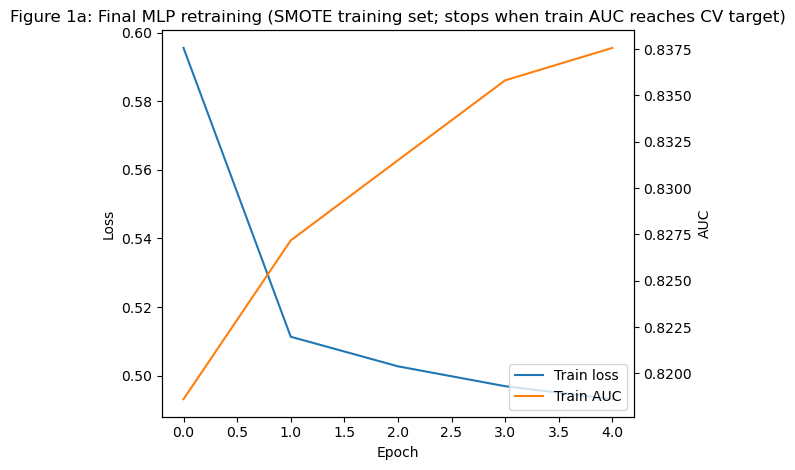

Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\figures\figure1_mlp_training_curve.png
Final retraining epochs: 5
Stopped once training AUC reached target: 0.8209969870501256


In [9]:
# Figure 1a: strict final retraining behaviour (training curves only because 100% training data is used).

print("Epochs recorded:", len(final_mlp_smote_train_hist["train_loss"]))
print("Train loss history:", final_mlp_smote_train_hist["train_loss"])
print("Train AUC history :", final_mlp_smote_train_hist["train_auc"])

fig, ax1 = plt.subplots()

ax1.plot(final_mlp_smote_train_hist["train_loss"], label="Train loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()
ax2.plot(final_mlp_smote_train_hist["train_auc"], label="Train AUC", color="tab:orange")
ax2.set_ylabel("AUC")

ax1.set_title("Figure 1a: Final MLP retraining (SMOTE training set; stops when train AUC reaches CV target)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure1_mlp_training_curve.png", dpi=300)
plt.show()

print("Saved:", FIGURES_DIR / "figure1_mlp_training_curve.png")
print("Final retraining epochs:", len(final_mlp_smote_train_hist["train_loss"]))
print("Stopped once training AUC reached target:", target_train_auc_smote)

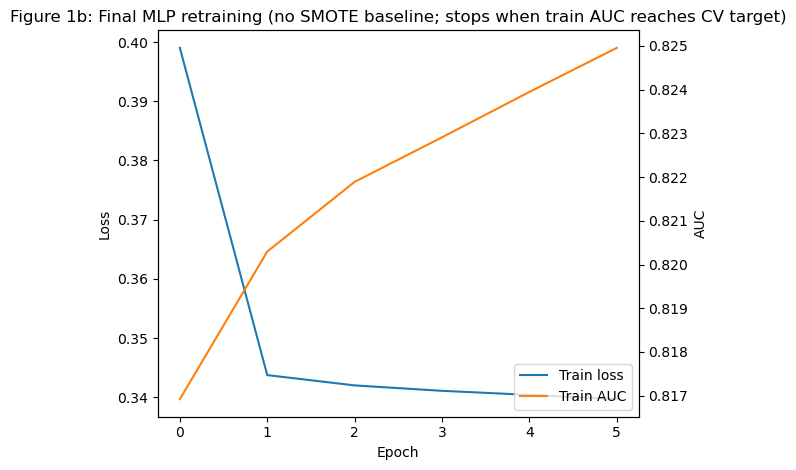

Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\figures\figure1b_mlp_training_curve_no_smote.png
Final retraining epochs (no SMOTE): 6
Stopped once training AUC reached target (no SMOTE): 0.824546518714618


In [10]:
# Figure 1b: final MLP retraining without SMOTE (baseline comparison).
# I include this so the baseline retraining dynamics can be compared directly to the SMOTE retraining in Figure 1.
# I place this next to Figure 1 so I can compare the baseline retraining behaviour to the SMOTE retraining directly.

fig, ax1 = plt.subplots()

ax1.plot(final_mlp_no_smote_train_hist["train_loss"], label="Train loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()
ax2.plot(final_mlp_no_smote_train_hist["train_auc"], label="Train AUC", color="tab:orange")
ax2.set_ylabel("AUC")

ax1.set_title("Figure 1b: Final MLP retraining (no SMOTE baseline; stops when train AUC reaches CV target)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure1b_mlp_training_curve_no_smote.png", dpi=300)
plt.show()

print("Saved:", FIGURES_DIR / "figure1b_mlp_training_curve_no_smote.png")
print("Final retraining epochs (no SMOTE):", len(final_mlp_no_smote_train_hist["train_loss"]))
print("Stopped once training AUC reached target (no SMOTE):", target_train_auc_no_smote)

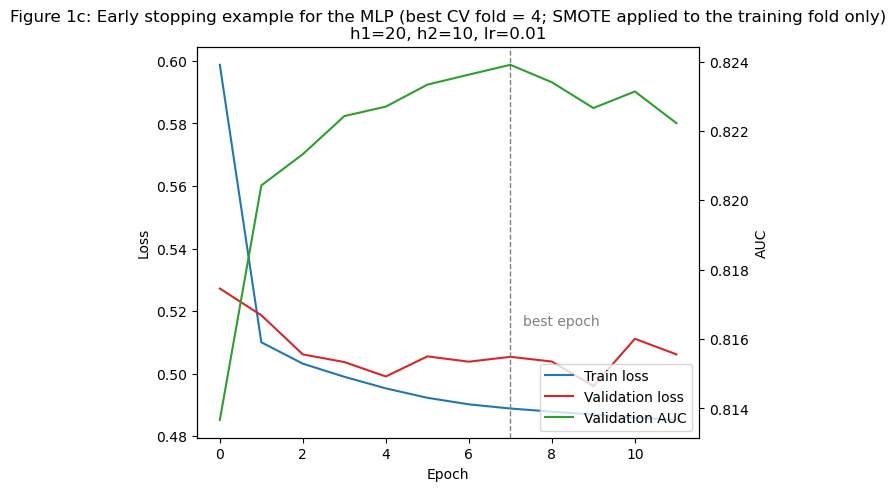

Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\figures\figure1c_mlp_early_stopping_example.png


In [11]:
# Figure 1c: early stopping example from CV (train vs validation curves).
# This figure supports the discussion of generalisation error and Caruana-style early stopping.

with open(MODELS_DIR / "mlp_early_stopping_example_smote.json", "r") as f:
    ex = json.load(f)

hist = ex["history"]
best_epoch = ex["best_epoch"]
cfg = ex["cfg"]
fold = ex["fold"]

fig, ax1 = plt.subplots()
fig.set_constrained_layout(True)

ax1.plot(hist["train_loss"], label="Train loss", color="tab:blue")
ax1.plot(hist["val_loss"], label="Validation loss", color="tab:red")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax1.axvline(best_epoch, linestyle="--", color="gray", linewidth=1)

# Place the text slightly above the validation-loss curve at the best epoch so it stays visible.
y_text = float(hist["val_loss"][best_epoch]) + 0.01
ax1.text(best_epoch + 0.3, y_text, "best epoch", color="gray")

ax2 = ax1.twinx()
ax2.plot(hist["val_auc"], label="Validation AUC", color="tab:green")
ax2.set_ylabel("AUC")

ax1.set_title(
    f"Figure 1c: Early stopping example for the MLP (best CV fold = {fold}; SMOTE applied to the training fold only)\n"
    f"h1={cfg['h1']}, h2={cfg['h2']}, lr={cfg['lr']}"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

fig.savefig(FIGURES_DIR / "figure1c_mlp_early_stopping_example.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIGURES_DIR / "figure1c_mlp_early_stopping_example.png")

## Notes and limitations (fairness and practicality)

- **Different model-selection protocols:** I use 5-fold CV for the MLP but a single hold-out validation split for the SVM because cross-validating the SVM (especially with RBF) is computationally expensive at this dataset size.
- **Different imbalance strategies:** the MLP uses **SMOTE** (data-level balancing), while the SVM uses **class_weight="balanced"** (cost-sensitive learning). This avoids inflating the SVM training set while still addressing imbalance.
- **Strict retraining stopping rule:** during final MLP retraining I stop when **training AUC reaches the best mean validation AUC from CV**. This is a practical heuristic for a strict retraining step, but training AUC is not guaranteed to correspond to the same generalisation point as validation AUC.
**Practical note:** in this run, the CV-derived target is about 0.82, and because the SMOTE-balanced training set can be easier to fit, the retraining step can sometimes reach the target in only a few epochs. This is expected under the heuristic and does not imply the model has fully converged.
- **Default operating points for confusion matrices:** the MLP confusion matrix uses a probability threshold of 0.5, while the SVM uses the default decision threshold (score >= 0). These are standard defaults and are not tuned to maximise recall.

## Group baseline on the ROC figure

The group baseline is **83.94% test accuracy** computed using the same dataset setup: stratified subsample to 100,000 rows, 21 features, and a stratified 80/20 split.

Accuracy is not an ROC quantity, so it is shown in Figure 2 only as a reference annotation, allowing the ROC/AUC results to be compared against the earlier baseline in one place.

ROC curves are computed from continuous prediction scores (MLP probabilities and SVM decision margins), making AUC threshold-independent.

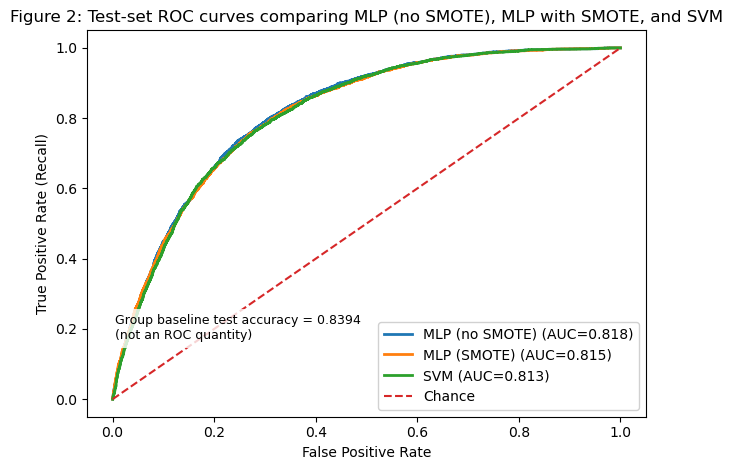

Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\figures\figure2_roc_comparison.png


In [12]:
# MLP produces probabilities (sigmoid output).
# I report two MLP variants here:
# 1) a no-SMOTE baseline trained on the original imbalanced training set
# 2) an SMOTE extension trained on the SMOTE-balanced training set
mlp_no_smote_test_prob = mlp_predict_proba(final_mlp_no_smote, X_test_std)
mlp_smote_test_prob = mlp_predict_proba(final_mlp_smote, X_test_std)

# SVM ROC/AUC uses decision_function() scores (as described above).
# These margin distances provide a continuous score, which is suitable for ROC/AUC.
svm_test_score = final_svm.decision_function(X_test_std)

# Compute ROC curves on the same held-out test set for a fair comparison.
fpr_mlp_no, tpr_mlp_no, _ = roc_curve(y_test, mlp_no_smote_test_prob)
fpr_mlp_sm, tpr_mlp_sm, _ = roc_curve(y_test, mlp_smote_test_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_test_score)

fig, ax = plt.subplots()

# I plot the no-SMOTE baseline first, then the SMOTE extension, then the SVM.
# This ordering makes it straightforward to compare the effect of adding SMOTE to the MLP.
ax.plot(
    fpr_mlp_no,
    tpr_mlp_no,
    color="tab:blue",
    linewidth=2,
    label=f"MLP (no SMOTE) (AUC={roc_auc_score(y_test, mlp_no_smote_test_prob):.3f})"
)
ax.plot(
    fpr_mlp_sm,
    tpr_mlp_sm,
    color="tab:orange",
    linewidth=2,
    label=f"MLP (SMOTE) (AUC={roc_auc_score(y_test, mlp_smote_test_prob):.3f})"
)
ax.plot(
    fpr_svm,
    tpr_svm,
    color="tab:green",
    linewidth=2,
    label=f"SVM (AUC={roc_auc_score(y_test, svm_test_score):.3f})"
)

# Chance diagonal for reference.
ax.plot([0, 1], [0, 1], linestyle="--", color="tab:red", label="Chance")

GROUP_BASELINE_ACC = 0.8394
# I include the group-work baseline (83.94% test accuracy under the same dataset setup) as a reference marker.
# Accuracy is not an ROC quantity, so I treat this as a visual reference marker only.
ax.text(
    0.05, 0.20,
    f"Group baseline test accuracy = {GROUP_BASELINE_ACC:.4f}\n(not an ROC quantity)",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("Figure 2: Test-set ROC curves comparing MLP (no SMOTE), MLP with SMOTE, and SVM"
)
ax.legend(loc="lower right", framealpha=0.9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure2_roc_comparison.png", dpi=300)
plt.show()

print("Saved:", FIGURES_DIR / "figure2_roc_comparison.png")

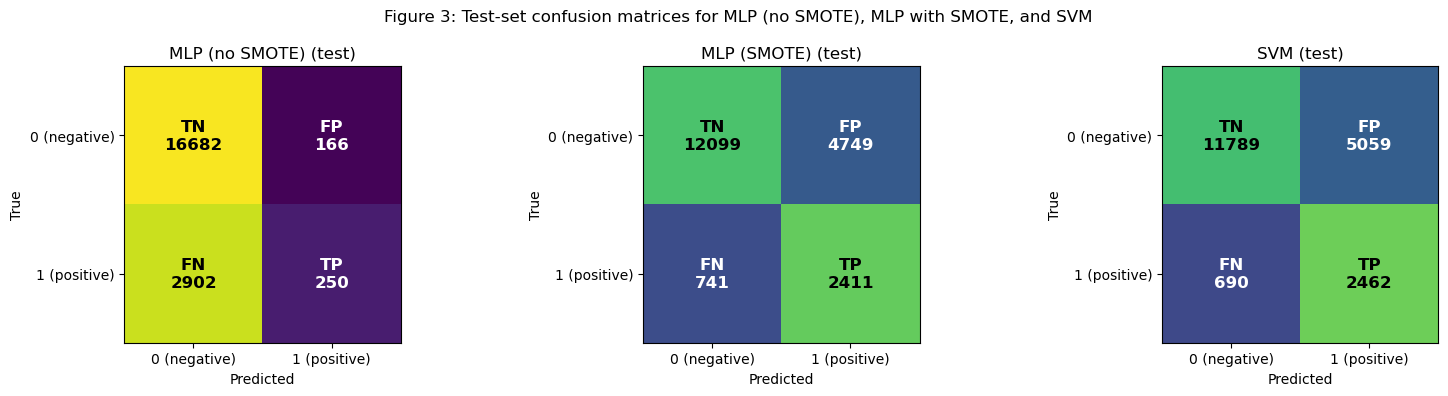

Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\figures\figure3_confusion_matrices_test.png


In [13]:
def plot_cm(ax, cm_counts, cm_colour, title, vmin=None, vmax=None):
    labels = np.array([["TN", "FP"], ["FN", "TP"]])
    ax.imshow(cm_colour, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0 (negative)", "1 (positive)"])
    ax.set_yticklabels(["0 (negative)", "1 (positive)"])
    for (i, j), val in np.ndenumerate(cm_counts):
        txt_color = "white" if cm_colour[i, j] < 0.45 else "black"
        ax.text(
            j, i, f"{labels[i, j]}\n{int(val)}",
            ha="center", va="center",
            color=txt_color,
            fontsize=12,
            fontweight="bold"
        )

# MLP confusion matrix uses probability threshold 0.5.
# I compute metrics for both MLP variants so the effect of SMOTE can be compared at a fixed threshold.
mlp_no_smote_test_prob = mlp_predict_proba(final_mlp_no_smote, X_test_std)
mlp_no_smote_test_metrics = metrics_from_probs(y_test, mlp_no_smote_test_prob)

mlp_smote_test_prob = mlp_predict_proba(final_mlp_smote, X_test_std)
mlp_smote_test_metrics = metrics_from_probs(y_test, mlp_smote_test_prob)

# SVM confusion matrix uses decision score threshold 0 (default SVM decision boundary).
svm_test_score = final_svm.decision_function(X_test_std)
svm_test_pred = (svm_test_score >= 0).astype(int)
svm_cm = confusion_matrix(y_test, svm_test_pred)

def row_normalise_cm(cm):
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0.0] = 1.0
    return cm / row_sums

cm_no_counts = mlp_no_smote_test_metrics["cm"]
cm_sm_counts = mlp_smote_test_metrics["cm"]
cm_svm_counts = svm_cm

cm_no_colour = row_normalise_cm(cm_no_counts)
cm_sm_colour = row_normalise_cm(cm_sm_counts)
cm_svm_colour = row_normalise_cm(cm_svm_counts)

vmin = 0.0
vmax = 1.0

# I plot three confusion matrices on the same test set:
# no-SMOTE MLP baseline, SMOTE MLP extension, and SVM.
# Using the same dataset split and thresholding rules keeps the comparison consistent.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_cm(axes[0], cm_no_counts, cm_no_colour, "MLP (no SMOTE) (test)", vmin=vmin, vmax=vmax)
plot_cm(axes[1], cm_sm_counts, cm_sm_colour, "MLP (SMOTE) (test)", vmin=vmin, vmax=vmax)
plot_cm(axes[2], cm_svm_counts, cm_svm_colour, "SVM (test)", vmin=vmin, vmax=vmax)
fig.suptitle("Figure 3: Test-set confusion matrices for MLP (no SMOTE), MLP with SMOTE, and SVM")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure3_confusion_matrices_test.png", dpi=300)
plt.show()

print("Saved:", FIGURES_DIR / "figure3_confusion_matrices_test.png")

For Figure 3, the cell colours are row normalised to represent within-class rates, while the numbers inside each cell show the raw counts. Predictions use the default decision thresholds for each model (MLP probability >= 0.5 and SVM margin score >= 0), which are not tuned.

## Supplementary negative result: removing weight decay

To justify the L2 regularisation choice, a controlled comparison is run where the architecture and learning rate are kept the same but weight decay is removed.

As a small negative-control experiment, I remove weight decay while keeping the same retraining target. This run does not produce a clear improvement, so I retain weight decay in the final setup for consistency with the selected regularised training protocol. I include the result as supplementary material to document this implementation choice.

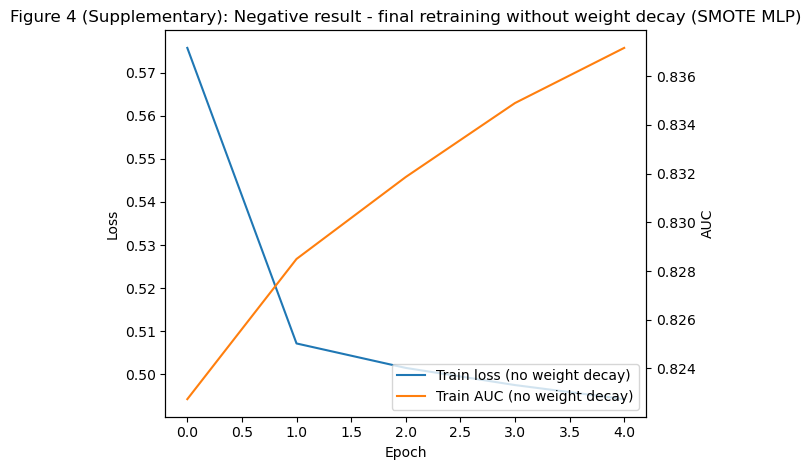

Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\figures\figure4_negative_no_weight_decay.png


In [14]:
# Negative result: remove weight decay while keeping the same strict stopping target.
# I run this on the SMOTE final-retraining setup, because that is the extension model.

mlp_smote_no_wd, hist_smote_no_wd = train_mlp_until_target_train_auc(
    X_train_sm, y_train_sm,
    h1=best_mlp_smote["h1"],
    lr=best_mlp_smote["lr"],
    target_train_auc=target_train_auc_smote,
    momentum=MOMENTUM,
    weight_decay=0.0,
    max_epochs=200
)

fig, ax1 = plt.subplots()
ax1.plot(hist_smote_no_wd["train_loss"], label="Train loss (no weight decay)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()
ax2.plot(hist_smote_no_wd["train_auc"], label="Train AUC (no weight decay)", color="tab:orange")
ax2.set_ylabel("AUC")

ax1.set_title("Figure 4 (Supplementary): Negative result - final retraining without weight decay (SMOTE MLP)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure4_negative_no_weight_decay.png", dpi=300)
plt.show()

print("Saved:", FIGURES_DIR / "figure4_negative_no_weight_decay.png")

# Evaluation only (no retraining)

This section reloads the saved models and evaluates them on the held-out test set **without retraining**.  
I use this as my fresh kernel check for reproducibility.

## Marker instructions (fresh kernel run)

You can run the evaluation cell below directly in a fresh kernel. It is self-contained and performs the following steps:

1. Loads the saved standardised test set  
   - `models/X_test_std.npy`  
   - `models/y_test.npy`

2. Rebuilds the MLP architecture and loads the saved weights for both variants  
   - **No SMOTE baseline:** `models/mlp_no_smote.pt` + `models/mlp_config_no_smote.json`  
   - **SMOTE extension:** `models/mlp_smote.pt` + `models/mlp_config_smote.json`

3. Loads the saved SVM model  
   - `models/svm.pkl`

4. Prints the final test metrics and confusion matrices

5. Regenerates the test figures  
   - **Figure 2:** ROC curves (test set)  
   - **Figure 3:** confusion matrices (test set)

## Note on duplication

Earlier in the notebook I generate the same test figures immediately after training. This evaluation only cell reproduces the same test metrics and **Figures 2 to 3** by reloading the saved artifacts from disk, which is useful after a restart and avoids retraining.

Loaded X_test_std: (20000, 21)
Loaded y_test    : (20000,) positive rate: 0.1576

Final test-set results (evaluation-only, no retraining)
MLP (no SMOTE): acc=0.847 recall=0.079 auc=0.818
MLP (SMOTE)   : acc=0.726 recall=0.765 auc=0.815
SVM           : acc=0.713 recall=0.781 auc=0.813

MLP (no SMOTE) confusion matrix:
 [[16682   166]
 [ 2902   250]]

MLP (SMOTE) confusion matrix:
 [[12099  4749]
 [  741  2411]]

SVM confusion matrix:
 [[11789  5059]
 [  690  2462]]


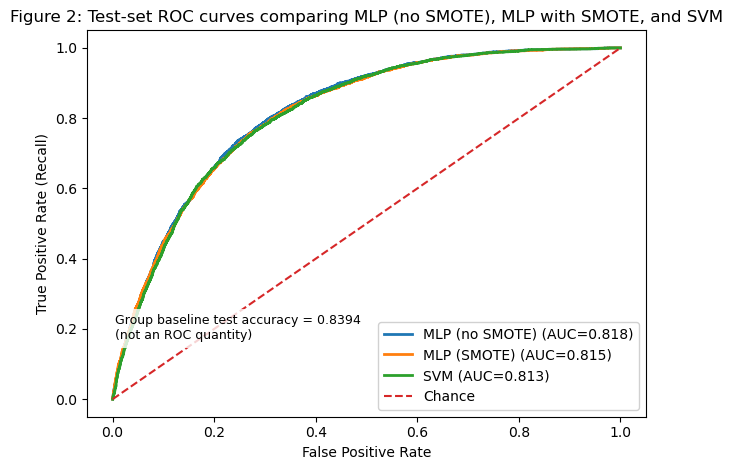

Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\figures\figure2_roc_comparison.png


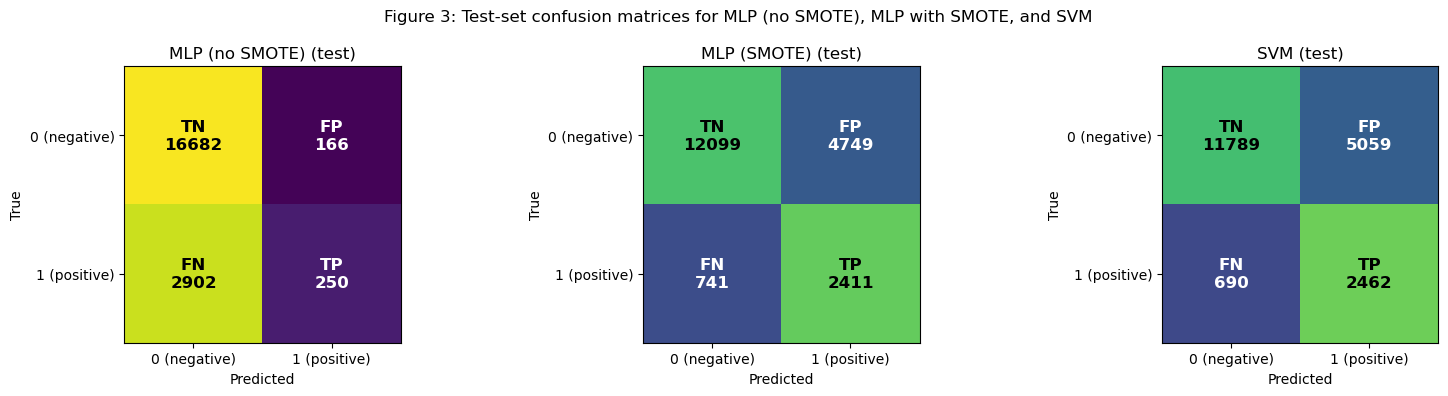

Saved: C:\Users\mario\OneDrive\Escritorio\INM427 FINAL\figures\figure3_confusion_matrices_test.png


In [15]:
# Evaluation-only (no training).
# This cell is self-contained so it can be run in a fresh kernel to reproduce the final test-set results.
#
# It:
# 1) loads the saved standardised test set (X_test_std.npy, y_test.npy)
# 2) rebuilds the MLP architecture and loads the saved weights (mlp_no_smote.pt + mlp_config_no_smote.json, mlp_smote.pt + mlp_config_smote.json)
# 3) loads the saved SVM model (svm.pkl)
# 4) prints test metrics and confusion matrices
# 5) regenerates Figures 2 and 3

import json
from pathlib import Path

import joblib
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score,
    confusion_matrix, roc_curve
)

ROOT = Path(".").resolve()
MODELS_DIR = ROOT / "models"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load the saved test set (already standardised in the training notebook).
# Using the saved standardised array avoids refitting the scaler in a fresh kernel.
X_test_std = np.load(MODELS_DIR / "X_test_std.npy")
y_test = np.load(MODELS_DIR / "y_test.npy")

print("Loaded X_test_std:", X_test_std.shape)
print("Loaded y_test    :", y_test.shape, "positive rate:", float(y_test.mean()))

class MLP(nn.Module):
    """
    Two-hidden-layer MLP for binary classification.

    The architecture must match the training notebook; otherwise the saved weights will not load correctly.
    The output is a single logit, so sigmoid(logit) gives the positive-class probability.
    """
    def __init__(self, input_dim: int, h1: int, h2: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

def mlp_predict_proba(model: nn.Module, X: np.ndarray) -> np.ndarray:
    """
    Convert logits to probabilities for ROC/AUC and threshold-based metrics.
    """
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X, dtype=torch.float32)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

def metrics_from_probs(y_true, y_prob, threshold: float = 0.5):
    """
    Compute accuracy/recall/confusion matrix at a fixed threshold, and AUC as a threshold-free metric.
    """
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "cm": confusion_matrix(y_true, y_pred)
    }

def plot_cm(ax, cm_counts, cm_colour, title, vmin=None, vmax=None):
    """
    Plot a labelled confusion matrix (TN/FP/FN/TP) to support the written discussion.
    """
    labels = np.array([["TN", "FP"], ["FN", "TP"]])
    ax.imshow(cm_colour, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0 (negative)", "1 (positive)"])
    ax.set_yticklabels(["0 (negative)", "1 (positive)"])
    for (i, j), val in np.ndenumerate(cm_counts):
        txt_color = "white" if cm_colour[i, j] < 0.45 else "black"
        ax.text(
            j, i, f"{labels[i, j]}\n{int(val)}",
            ha="center", va="center",
            color=txt_color,
            fontsize=12,
            fontweight="bold"
        )

def row_normalise_cm(cm):
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0.0] = 1.0
    return cm / row_sums

# Load the saved models.
# I keep the file names explicit here so it is obvious what needs to be present in the submitted zip.
svm_loaded = joblib.load(MODELS_DIR / "svm.pkl")

with open(MODELS_DIR / "mlp_config_no_smote.json", "r") as f:
    mlp_cfg_no = json.load(f)

with open(MODELS_DIR / "mlp_config_smote.json", "r") as f:
    mlp_cfg_sm = json.load(f)

h1_no = int(mlp_cfg_no["h1"])
h2_no = int(mlp_cfg_no["h2"])
h1_sm = int(mlp_cfg_sm["h1"])
h2_sm = int(mlp_cfg_sm["h2"])

mlp_no_smote_loaded = MLP(
    input_dim=X_test_std.shape[1],
    h1=h1_no,
    h2=h2_no
)
mlp_no_smote_loaded.load_state_dict(torch.load(MODELS_DIR / "mlp_no_smote.pt", map_location="cpu"))
mlp_no_smote_loaded.eval()

mlp_smote_loaded = MLP(
    input_dim=X_test_std.shape[1],
    h1=h1_sm,
    h2=h2_sm
)
mlp_smote_loaded.load_state_dict(torch.load(MODELS_DIR / "mlp_smote.pt", map_location="cpu"))
mlp_smote_loaded.eval()

# Evaluate on the test set (no retraining).
mlp_no_te_prob = mlp_predict_proba(mlp_no_smote_loaded, X_test_std)
mlp_sm_te_prob = mlp_predict_proba(mlp_smote_loaded, X_test_std)

# SVM uses decision_function for ROC/AUC; this is the same score used in the earlier evaluation cells.
svm_te_score = svm_loaded.decision_function(X_test_std)

mlp_no_te_metrics = metrics_from_probs(y_test, mlp_no_te_prob)
mlp_sm_te_metrics = metrics_from_probs(y_test, mlp_sm_te_prob)

svm_te_pred = (svm_te_score >= 0).astype(int)
svm_te_acc = accuracy_score(y_test, svm_te_pred)
svm_te_rec = recall_score(y_test, svm_te_pred)
svm_te_auc = roc_auc_score(y_test, svm_te_score)
svm_te_cm = confusion_matrix(y_test, svm_te_pred)

print("\nFinal test-set results (evaluation-only, no retraining)")
print("MLP (no SMOTE): acc={:.3f} recall={:.3f} auc={:.3f}".format(
    mlp_no_te_metrics["accuracy"], mlp_no_te_metrics["recall"], mlp_no_te_metrics["auc"]
))
print("MLP (SMOTE)   : acc={:.3f} recall={:.3f} auc={:.3f}".format(
    mlp_sm_te_metrics["accuracy"], mlp_sm_te_metrics["recall"], mlp_sm_te_metrics["auc"]
))
print("SVM           : acc={:.3f} recall={:.3f} auc={:.3f}".format(
    svm_te_acc, svm_te_rec, svm_te_auc
))
print("\nMLP (no SMOTE) confusion matrix:\n", mlp_no_te_metrics["cm"])
print("\nMLP (SMOTE) confusion matrix:\n", mlp_sm_te_metrics["cm"])
print("\nSVM confusion matrix:\n", svm_te_cm)

# Figure 2: ROC curves (test set).
# AUC is computed using the continuous outputs (probabilities for MLP, decision scores for SVM).
fpr_mlp_no, tpr_mlp_no, _ = roc_curve(y_test, mlp_no_te_prob)
fpr_mlp_sm, tpr_mlp_sm, _ = roc_curve(y_test, mlp_sm_te_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_te_score)

fig, ax = plt.subplots()
ax.plot(
    fpr_mlp_no,
    tpr_mlp_no,
    color="tab:blue",
    linewidth=2,
    label=f"MLP (no SMOTE) (AUC={roc_auc_score(y_test, mlp_no_te_prob):.3f})"
)
ax.plot(
    fpr_mlp_sm,
    tpr_mlp_sm,
    color="tab:orange",
    linewidth=2,
    label=f"MLP (SMOTE) (AUC={roc_auc_score(y_test, mlp_sm_te_prob):.3f})"
)
ax.plot(
    fpr_svm,
    tpr_svm,
    color="tab:green",
    linewidth=2,
    label=f"SVM (AUC={roc_auc_score(y_test, svm_te_score):.3f})"
)
ax.plot([0, 1], [0, 1], linestyle="--", color="tab:red", label="Chance")

# I include the group baseline (83.94% test accuracy from the group setup) as a reference marker.
# Accuracy is not an ROC quantity, so this is a visual reference only rather than an ROC-based comparison.
GROUP_BASELINE_ACC = 0.8394
ax.text(
    0.05, 0.20,
    f"Group baseline test accuracy = {GROUP_BASELINE_ACC:.4f}\n(not an ROC quantity)",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("Figure 2: Test-set ROC curves comparing MLP (no SMOTE), MLP with SMOTE, and SVM"
)
ax.legend(loc="lower right", framealpha=0.9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure2_roc_comparison.png", dpi=300)
plt.show()

print("Saved:", FIGURES_DIR / "figure2_roc_comparison.png")

# Figure 3: Confusion matrices (test set).
# The MLP confusion matrices use threshold 0.5. The SVM uses the default decision boundary at 0.
cm_no_counts = mlp_no_te_metrics["cm"]
cm_sm_counts = mlp_sm_te_metrics["cm"]
cm_svm_counts = svm_te_cm

cm_no_colour = row_normalise_cm(cm_no_counts)
cm_sm_colour = row_normalise_cm(cm_sm_counts)
cm_svm_colour = row_normalise_cm(cm_svm_counts)

vmin = 0.0
vmax = 1.0

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_cm(axes[0], cm_no_counts, cm_no_colour, "MLP (no SMOTE) (test)", vmin=vmin, vmax=vmax)
plot_cm(axes[1], cm_sm_counts, cm_sm_colour, "MLP (SMOTE) (test)", vmin=vmin, vmax=vmax)
plot_cm(axes[2], cm_svm_counts, cm_svm_colour, "SVM (test)", vmin=vmin, vmax=vmax)
fig.suptitle("Figure 3: Test-set confusion matrices for MLP (no SMOTE), MLP with SMOTE, and SVM")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure3_confusion_matrices_test.png", dpi=300)
plt.show()

print("Saved:", FIGURES_DIR / "figure3_confusion_matrices_test.png")

### Note
For Figure 3, the cell colours are row normalised to represent within-class rates, while the numbers inside each cell show the raw counts. Predictions use the default decision thresholds for each model (MLP probability >= 0.5 and SVM margin score >= 0), which are not tuned.